# 🎬 Top 1000 IMDb Movies - Data Analysis

This project is EDA(Exploratory Data Analysis) of the Top 1000 highest-rated movies on IMDb. Using tools like **Pandas, NumPy, Seaborn, Squarify, Scipy and Matplotlib**.

Is there a correlation for movies to either be flop or hit based on their genre, ratings, certificates ?. Thats what we are gonna analyse and find from this dataset 

---

## 📌 Objective

The goal of this analysis is to identify high-value investment drivers in film production by examining:

- **Financial Scalability:** How certifications (U, UA, R) influence market reach.  
- **Acclaim vs. Profit:** Whether ratings correlate with gross revenue.  
- **Genre Dominance:** Which genres statistically outperform others.



## 💡   What I Found 

1. **Ratings barely predict revenue:** IMDb ratings have a very weak correlation (**0.10**). Even if  ratings are nice, but it won't guarantee higher box office too.
2. **UA certification = more money:** UA-rated films made almost $39 billion total compared to $11.5B for A-rated films. Wider audiences mean bigger profits.
3. **Genre matters:** Statistical testing (ANOVA) proved that genre significantly affects earnings, but certification doesn't determine quality



## 📊 Questions that will be answered
- Which films have the highest IMDb and Meta scores?  
- Do certifications correlate with higher box office earnings?  
- How has revenue evolved over the past decade?  
- Are general-audience films more profitable than restricted ones?  
- Which genres dominate the top-rated films?


### Importing Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import squarify
from scipy.stats import pearsonr
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

## 1. Introduction

In [2]:
imdb=pd.read_csv("top_1000_movies_data.csv")
imdb.columns 

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [3]:
imdb.head(10)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,1994,A,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,"107,928,762"
7,https://m.media-amazon.com/images/M/MV5BNDE4OT...,Schindler's List,1993,A,195 min,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,"96,898,818"
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,"292,576,195"
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,1999,A,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,"37,030,102"


In [4]:
imdb.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [5]:
imdb['Genre'].value_counts()

Genre
Drama                        85
Drama, Romance               37
Comedy, Drama                35
Comedy, Drama, Romance       31
Action, Crime, Drama         30
                             ..
Action, Adventure, Family     1
Action, Crime, Mystery        1
Animation, Drama, Romance     1
Drama, War, Western           1
Adventure, Comedy, War        1
Name: count, Length: 202, dtype: int64

## 2. Data Cleaning & Feature Creation  

In [6]:
imdb['Gross'] = imdb['Gross'].replace(',', '', regex=True).astype(float)
imdb['Gross'] = pd.to_numeric(imdb['Gross'], errors='coerce') # coerce non-numeric to NaN

# Standardized Indian (U/A) and international (UA/U) certificates to a single format.
imdb['Certificate'] = imdb['Certificate'].replace({'UA': 'U/A', 'U': 'U/A'})

imdb[['Gross', 'Certificate']].info()
imdb['Gross'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gross        831 non-null    float64
 1   Certificate  899 non-null    object 
dtypes: float64(1), object(1)
memory usage: 15.8+ KB


count    8.310000e+02
mean     6.803475e+07
std      1.097500e+08
min      1.305000e+03
25%      3.253559e+06
50%      2.353089e+07
75%      8.075089e+07
max      9.366622e+08
Name: Gross, dtype: float64

In [7]:
gross_by_year = imdb.groupby('Released_Year')['Gross'].sum().sort_index(ascending=False)

recent_10_years = gross_by_year.head(10)
print(recent_10_years)

Released_Year
PG      1.738379e+08
2020    0.000000e+00
2019    2.406743e+09
2018    2.607757e+09
2017    2.061313e+09
2016    2.595557e+09
2015    2.462337e+09
2014    2.755629e+09
2013    1.285357e+09
2012    2.542616e+09
Name: Gross, dtype: float64


In [8]:
gross_sum = imdb.groupby('Certificate')['Gross'].sum()
gross_sum = gross_sum[gross_sum > 1e7]

print(gross_sum)

Certificate
A           1.149968e+10
Approved    4.169408e+07
G           4.959633e+08
PG          4.293186e+08
PG-13       1.440966e+09
Passed      1.250177e+08
R           3.482136e+09
U/A         3.885213e+10
Name: Gross, dtype: float64


## 3. EDA & Visualizations

#### I) Top 20 Most Rated Movies on IMDb and Their Ratings

- Looking at the 20 movies with the most ratings.
- The Shawshank Redemption leads with a 9.3 rating and over 2.3M votes massive audience engagement.


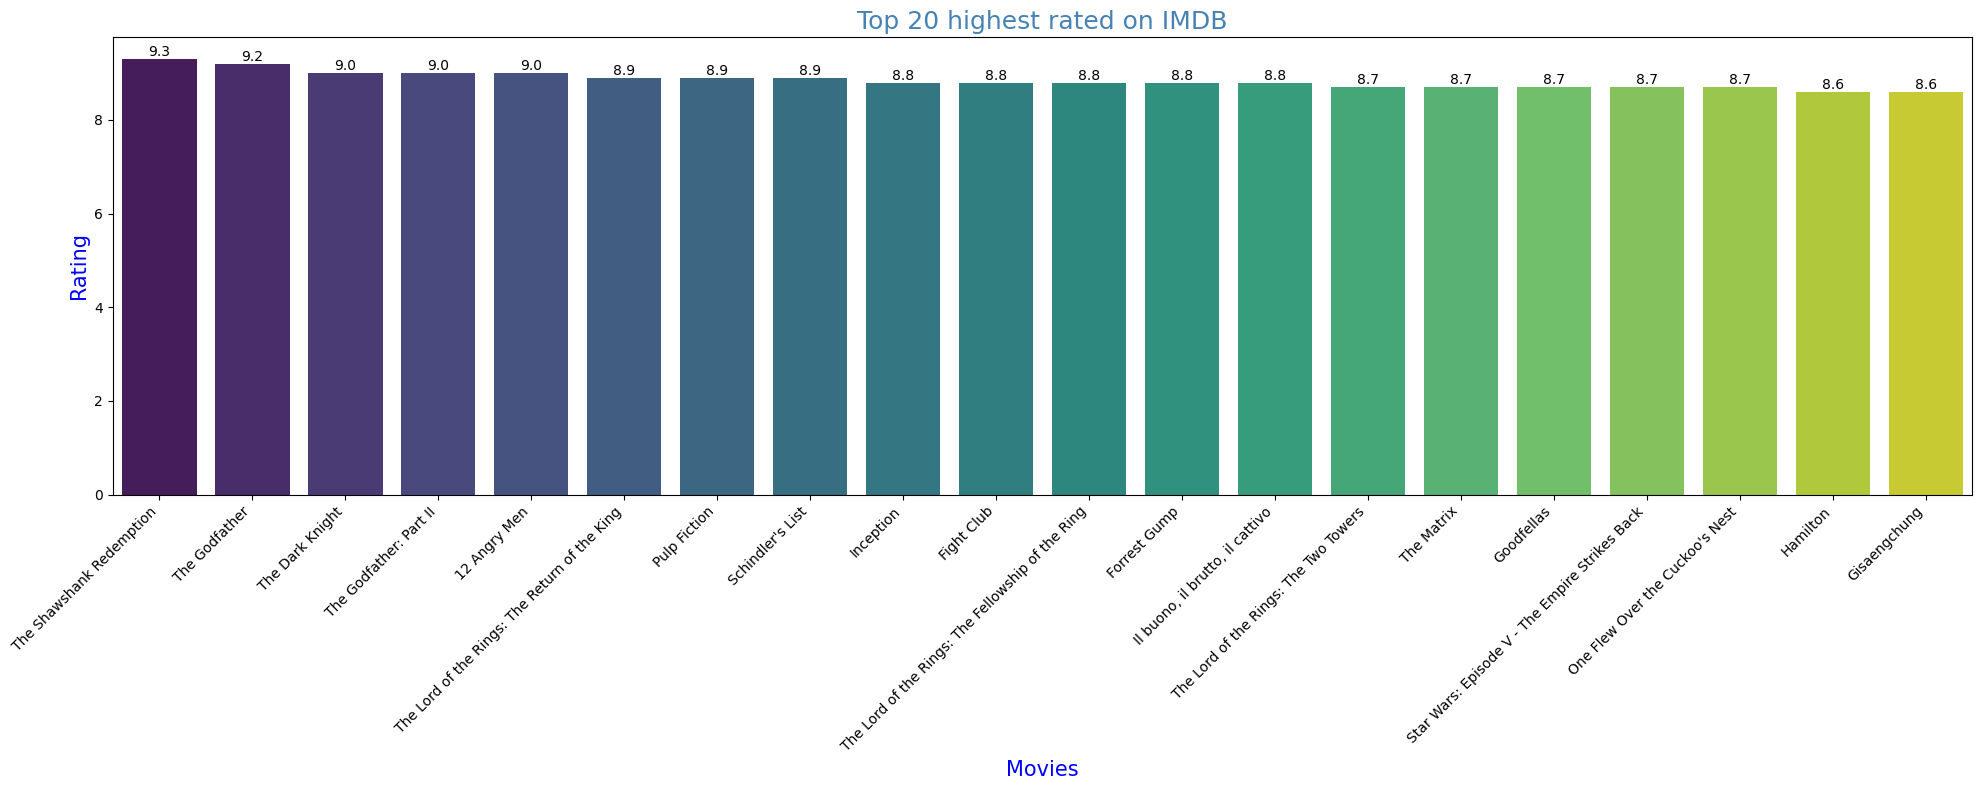

In [9]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(20,8))
ax=sns.barplot(x=imdb['Series_Title'].head(20), y=imdb['IMDB_Rating'].head(20), data=imdb, palette='viridis')
plt.title('Top 20 highest rated on IMDB',color='steelblue',fontsize='18')
plt.xlabel('Movies',color='blue',fontsize='15')
plt.xticks(imdb['Series_Title'].head(20),rotation=45,ha='right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f',color='black')
plt.ylabel('Rating',color='blue',fontsize='15')
plt.tight_layout()
plt.show()

#### II) Top 20 Movies by Meta Score

- The chart below is the top 20 movies based on the Meta scores.
- Top-ranked movies such as The Godfather (Meta score: 100) indicate exceptional critical acclaim.

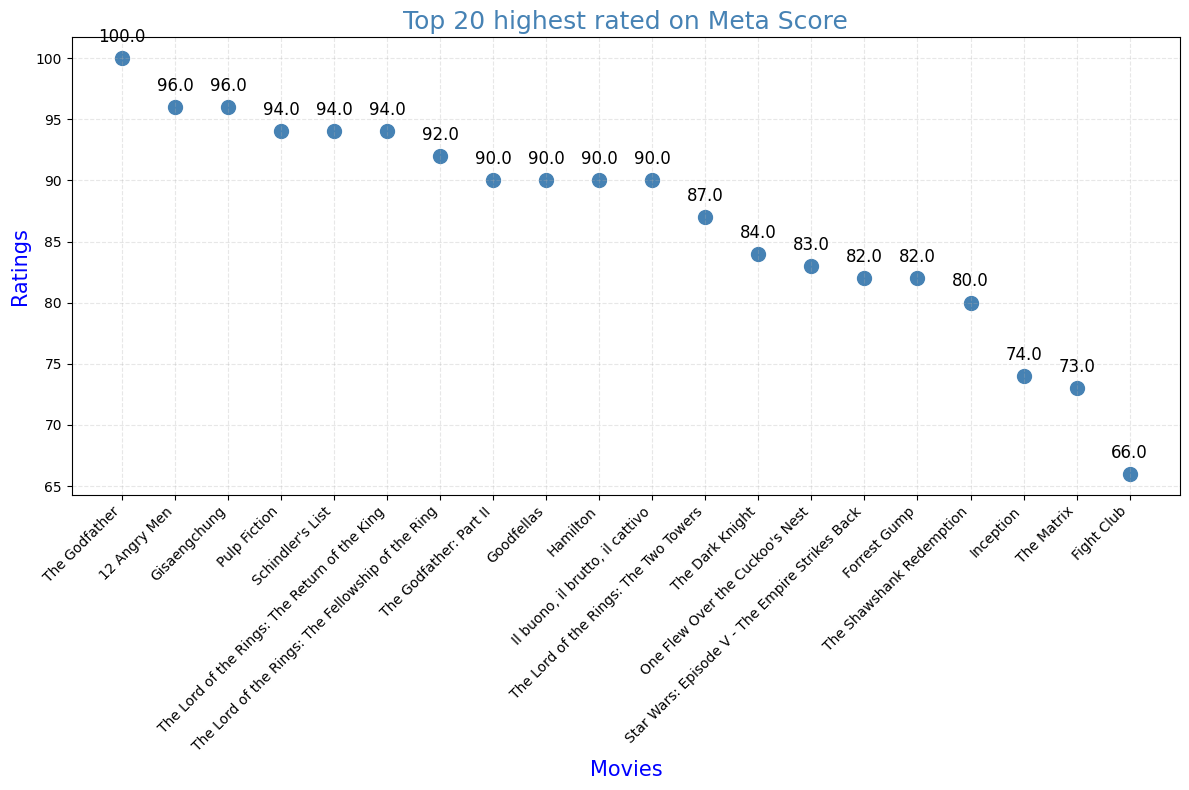

In [10]:
x = imdb['Series_Title'].head(20)
y = imdb['Meta_score'].head(20)
top20_sorted = imdb.head(20).sort_values(by='Meta_score', ascending=False)

x = top20_sorted['Series_Title']
y = top20_sorted['Meta_score']

plt.figure(figsize=(12, 8))
plt.scatter(range(20), y, color='steelblue', s=100)

for i, score in enumerate(y):
    plt.text(i, score + 1, str(score), ha="center", va="bottom", fontsize=12)

plt.title('Top 20 highest rated on Meta Score', color='steelblue', fontsize=18)
plt.xlabel('Movies', color='blue', fontsize=15)
plt.ylabel('Ratings', color='blue', fontsize=15)
plt.xticks(ticks=range(20), labels=x, rotation=45, ha="right")

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### III) Total Gross Earnings by Movie Certificate

- Analyzes how movie content ratings (U, UA, A, PG, R, etc.) relate to total gross earnings:
  1) Whether movies for a broader audience (U/PG) perform better commercially.
  2) How adult/restricted certificates (A, R, TV-MA) impact financial reach.
- Family/general audience movies (U/UA) earn the most, indicating broad commercial appeal.
- PG-13 and R films also perform well, showing some adult-oriented movies can achieve high financial success. In India, R-rated films are trending and therefore earning more than UA movies. 
- Niche certificates (TV-14, Unrated) generate minimal revenue, implying limited or non-theatrical releases.

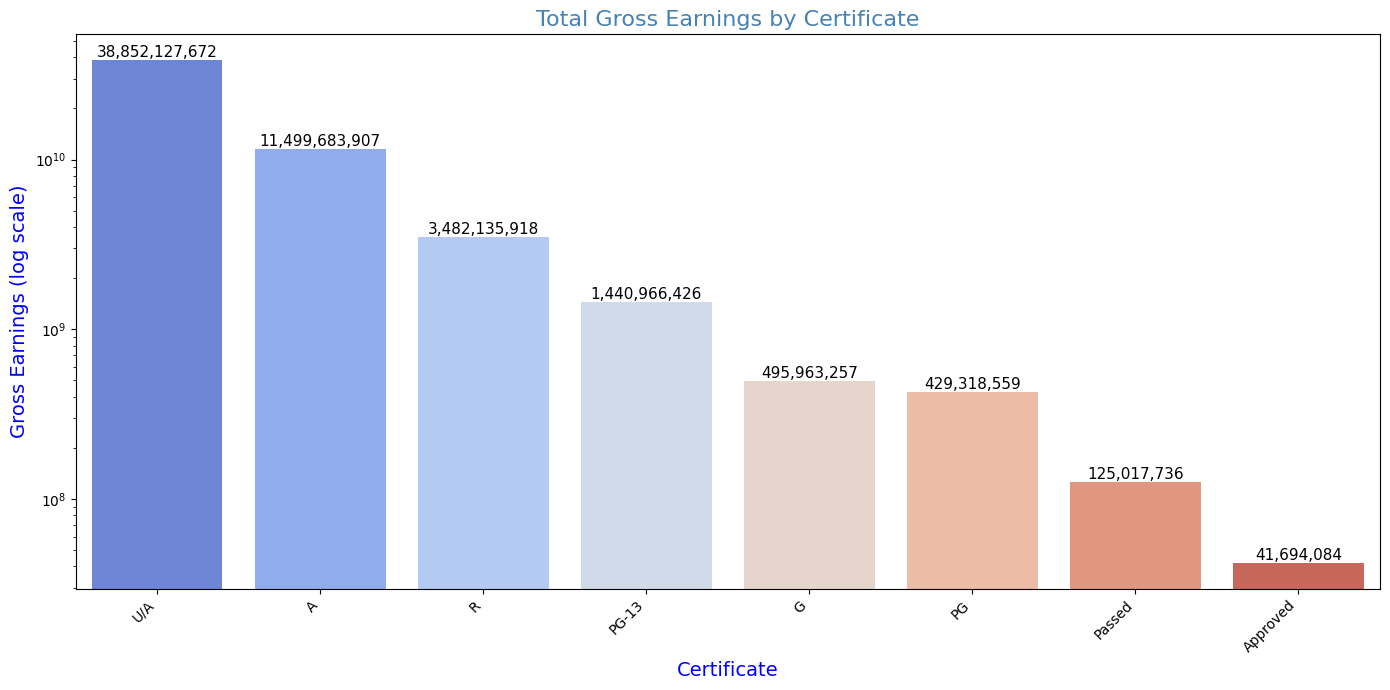

In [11]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

gross_sum_sorted = gross_sum.sort_values(ascending=False)

plt.figure(figsize=(14, 7))
ax = sns.barplot(x=gross_sum_sorted.index, y=gross_sum_sorted.values, palette='coolwarm')

ax.set_yscale('log') 
ax.set_title('Total Gross Earnings by Certificate', fontsize=16, color='steelblue')
ax.set_xlabel('Certificate', fontsize=14, color='blue')
ax.set_ylabel('Gross Earnings (log scale)', fontsize=14, color='blue')

plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2,height,f'{height:,.0f}',ha='center',va='bottom',fontsize=11,color='black')

plt.tight_layout()
plt.show()


#### IV) Total Gross Earnings of Top IMDb-Rated Movies (Recent 10 Valid Years)

- Total gross earnings from 2012-2019
- Removed  entries to ensure accuracy:
  1. 'PG' — a certificate mistakenly in the year column.
- Log scale used because the gross values range from millions to billions
- Each point represents total gross for that year, with exact earnings annotated above markers.

**Insights:**
- 2014 and 2018 were peak years
- Steady growth is noticed unitl 2020.
- Shows the rise of global blockbusters during this decade


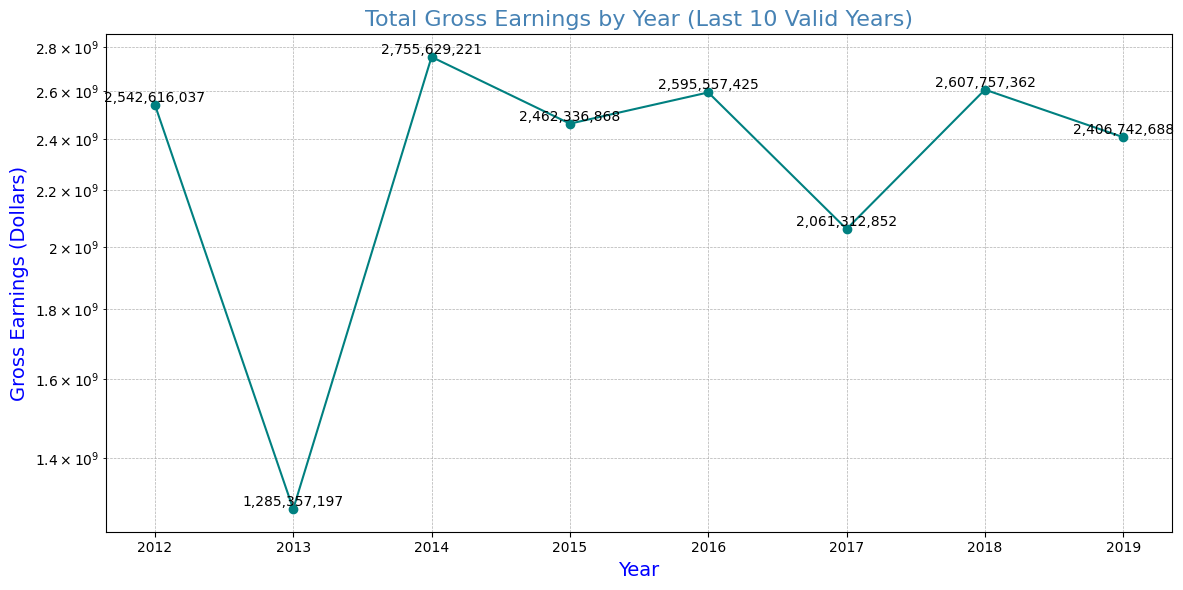

In [12]:

recent_10_years = recent_10_years[recent_10_years.index.astype(str).str.isnumeric()]
recent_10_years.index = recent_10_years.index.astype(int)


cleaned_gross = recent_10_years[recent_10_years.index != 2020]

plt.figure(figsize=(12, 6))
plt.plot(cleaned_gross.index, cleaned_gross.values, marker='o', linestyle='-', color='teal')

for x, y in zip(cleaned_gross.index, cleaned_gross.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=10, color='black')

plt.yscale('log')
plt.title('Total Gross Earnings by Year (Last 10 Valid Years)', fontsize=16, color='steelblue')
plt.xlabel('Year', fontsize=14, color='blue')
plt.ylabel('Gross Earnings (Dollars)', fontsize=14, color='blue')

plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

#### V) Top 5 Most Common Genres in IMDb’s Top 1000 Movies (Treemap)

- Top 5 genres by frequency. It is suprising to see how Drama appearing 724 times in the dataset, followed by Comedy (233) and Crime (189)

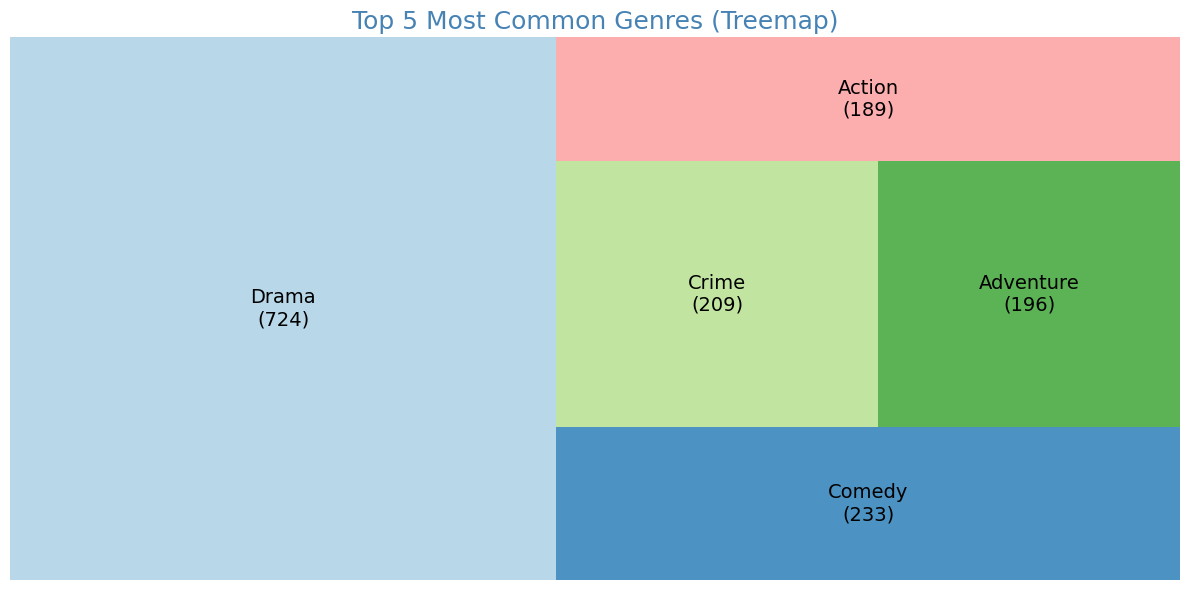

In [13]:
all_genres = imdb['Genre'].dropna().str.split(', ')
exploded_genres = all_genres.explode()

genre_counts = exploded_genres.value_counts()

top5_genres = genre_counts.head(5)

plt.figure(figsize=(12, 6))
squarify.plot(sizes=top5_genres.values,label=[f'{genre}\n({count})' for genre, count in zip(top5_genres.index, top5_genres.values)],color=plt.cm.Paired.colors[:5], alpha=0.8,text_kwargs={'fontsize': 14})

plt.axis('off')
plt.title('Top 5 Most Common Genres (Treemap)', fontsize=18, color='steelblue')
plt.tight_layout()
plt.show()

## 4. Statistical Testing  

#### VII) Does a Higher IMDb Rating Lead to Higher Gross Earnings?

**Hypotheses:**

- Null hypothesis ($H_0$): There is no correlation between IMDb rating and gross earnings.
- Alternative hypothesis ($H_1$): There is a correlation between IMDb rating and gross earnings.

**Objective:**  
We will use Pearson correlation to understand the relationship between a movie’s IMDb rating and its total gross which helps us prove that Revenue= Ratings.


In [14]:
imdb_corr= imdb.dropna(subset=['IMDB_Rating','Gross'])
corr,p_val=pearsonr(imdb_corr['IMDB_Rating'],imdb_corr['Gross'])
print(f"Correlation = {corr:.2f}, \033[1mP-Value = {p_val:.4f}\033[0m\n")

if p_val < 0.05:
    print(f"Result: Statistically significant but very weak correlation (r = {corr:.2f}) — "
          f"ratings are not a reliable predictor of revenue.")
else:
    print("Result: No statistically significant relationship between ratings and gross earnings.")


Correlation = 0.10, P-Value = 0.0057

Result: Statistically significant but very weak correlation (r = 0.10) — ratings are not a reliable predictor of revenue.


#### VIII) Does Movie Genre Affect Gross Earnings?

- Note: Multi-genre movies are classified by their primary genre only.

**Hypotheses:**

- Null hypothesis ($H_0$): Mean gross earnings are the same across all movie genres.
- Alternative hypothesis ($H_1$): At least one genre’s mean gross earnings differ.

**Objective:**  
We wil use one-way ANOVA to test whether average gross earnings vary significantly by movie genre. 
The result helps identify if certain genres tend to be more commercially successful on average.


In [15]:
imdb['Main_Genre'] = imdb['Genre'].dropna().str.split(',').str[0]

groups = [group['Gross'].dropna() for _, group in imdb.groupby('Main_Genre') if group['Gross'].notna().sum() > 2]

f_stat, p_val = f_oneway(*groups)

print(f"F-statistic = {f_stat:.2f}, \033[1mP-value = {p_val:.2e}\033[0m\n")


if p_val < 0.05:
    print("Result: Movie genre has a measurable impact on gross revenue.")
else:
    print("Result: No evidence that movie genre impacts gross revenue.")


F-statistic = 16.69, P-value = 2.15e-25

Result: Movie genre has a measurable impact on gross revenue.


#### IX) Does Movie Certificate Relate to Rating Level?

**Hypotheses:**

- Null hypothesis ($H_0$): Movie certificate and rating level are independent (no relationship).
- Alternative hypothesis ($H_1$): Movie certificate and rating level are dependent (they affect each other).

**Objective:**  
Chi-square test  is used to determine whether a movie’s certification category (U, UA, R, etc.) is propertional with its IMDb rating level (Low, Medium, High).


In [16]:
imdb['rating_level']=pd.cut(imdb['IMDB_Rating'], bins=[0,5,7.5,10], labels=['Low','Medium','High'])
contingency = pd.crosstab(imdb['Certificate'], imdb['rating_level'])
display(contingency)
chi2, p_val, dof, expected = chi2_contingency(contingency)

print(f"Chi-square Statistic = {chi2:.2f}, \033[1mP-value = {p_val:.4f}\033[0m\n")

if p_val < 0.05:
    print("Result: Certificate and rating level are related (statistically significant).")
else:
    print("Result: Certificate and rating level are independent (no significant relationship).")


rating_level,High
Certificate,
16,1
A,197
Approved,11
G,12
GP,2
PG,37
PG-13,43
Passed,34
R,146


Chi-square Statistic = 0.00, P-value = 1.0000

Result: Certificate and rating level are independent (no significant relationship).


## 5. Key Insights & Takeaways  

## 🔍 Final Results

- **Top Rated Movies:** *The Shawshank Redemption* leads audience ratings, while *The Godfather* and *Citizen Kane* lead critic scores.
- **Highest Earnings:** U/A-certified films earn the most money because they reach a wider audience.
- **Revenue Over Time:** Movie earnings increase over time, with clear peaks in 2014 and 2018.
- **What Affects Profit:** Genre has a strong impact on revenue, while IMDb ratings have little influence.
- **Popular Genres:** Drama appears most often among top films, but Action and Adventure generate the highest revenue.

---

## 📊 Statistical Analysis Summary

| Test | Purpose | Result |
|-----|--------|--------|
| **Pearson Correlation** | Relationship between IMDb rating and gross revenue | Statistically significant but very weak (r = 0.10) |
| **One-Way ANOVA** | Impact of genre on average gross revenue | Genre has a significant effect |
| **Chi-Square Test** | Relationship between certification and rating levels | No significant relationship |

These results **support the trends observed during EDA and visualization**.

---

## 🎬 Business Insights & Recommendations

Based on the analysis, key takeaways for a **producer or investor** are:

- **Genre Matters:** Some genres consistently perform better financially and should be prioritized.
- **U/A Advantage:** U/A-rated films scale better commercially than restricted-rated films. But now in recent trends R-rated movies are earning more in India.
- **Ratings ≠ Revenue:** Strong ratings alone do not guarantee box office success.
- **Balanced Strategy:** Combining wide audience appeal with quality content improves both critical and commercial outcomes.
